## Momentum, Mean Reversion and Breakout Signals

**Developing signals on futures data and this comes in three stages:**

1. Generating the Volatility Estimate
2. Generating the signal
3. Backtesting the signal

## 1. Volatility EWMA Estimators

**Finding an estimate for the volatility after previously concluding that constant volatility is not a valid assumption.**

In [3]:
# Importing Data
import pandas as pd

df = pd.read_excel("C:/Users/Aksha/OneDrive/Documents/GitHub/systematic-alpha-research/01_data-cleaning/Signal_Project_Data_Cleaned.xlsx", sheet_name = "Data")
df.head()

,Date,EDOLLAR,SP500,US10,LEANHOG,JPY,GOLD,WHEAT,NIKKEI,COPPER,BITCOIN
0,1984-03-23,71.84001,464.55,-33.070302,-5.24,0.012126,1145.9,857.50,NaN,NaN,NaN
1,1984-03-26,71.91001,464.65,-32.914052,-5.36,0.012139,1147.6,860.50,NaN,NaN,NaN
2,1984-03-27,71.89001,465.45,-32.976552,-4.79,0.012140,1146.4,859.75,NaN,NaN,NaN
3,1984-03-28,71.89001,467.70,-32.632802,-4.44,0.012153,1149.4,857.50,NaN,NaN,NaN
4,1984-03-29,71.86001,466.40,-32.445302,-4.56,0.012147,1148.9,858.25,NaN,NaN,NaN


## Estimate 1.0 - Constant Volatility

**Getting an idea of average volatility in the data**

In [4]:
futures_vol1 = df[1:].diff().std()
print(futures_vol1)

futures_vol2_results = []
for col in df.columns[1:]:
    s = df[col].dropna().diff()
    futures_vol2_results.append((col,s.std()))
    futures_vol2 = pd.DataFrame(futures_vol2_results)

print(futures_vol2)

Date       0 days 19:11:53.163543235
EDOLLAR                       0.0742
SP500                      18.532178
US10                        0.433431
LEANHOG                     0.822816
JPY                         0.000059
GOLD                        9.956849
WHEAT                       8.752059
NIKKEI                    232.032758
COPPER                      0.042538
BITCOIN                   1155.88755
dtype: object
         0            1
0  EDOLLAR     0.074199
1    SP500    18.531262
2     US10     0.433412
3  LEANHOG     0.822776
4      JPY     0.000059
5     GOLD     9.956370
6    WHEAT     8.751677
7   NIKKEI   286.468982
8   COPPER     0.042538
9  BITCOIN  1155.887550


## Estimate 1.1 - Exponential Weighting

**Trialling using exponentially weighted averages before introducing some complexity into the idea**

In [5]:
futures_diff = df.diff()
print(futures_diff)

vol_dict = {}
for col in df.columns[1:]:
    s = df[col].diff()
    vol_dict[col] = s.ewm(span=32).std()
    
exp_results = pd.DataFrame(vol_dict) 
exp_results = exp_results.set_index(df["Date"])
print(exp_results)

        Date  EDOLLAR  SP500      US10  LEANHOG           JPY  GOLD  WHEAT  \
0        NaT      NaN    NaN       NaN      NaN           NaN   NaN    NaN   
1     3 days    0.070   0.10  0.156250   -0.120  1.300000e-05   1.7   3.00   
2     1 days   -0.020   0.80 -0.062500    0.570  1.000000e-06  -1.2  -0.75   
3     1 days    0.000   2.25  0.343750    0.350  1.300000e-05   3.0  -2.25   
4     1 days   -0.030  -1.30  0.187500   -0.120 -6.000000e-06  -0.5   0.75   
...      ...      ...    ...       ...      ...           ...   ...    ...   
10111 3 days    0.000   0.00  0.000000    0.000  0.000000e+00   0.0   0.00   
10112 1 days   -0.085 -12.25 -0.718750    1.075 -3.700000e-05  15.8  -2.00   
10113 1 days   -0.075 -45.75 -0.296875    0.125 -5.100000e-05  -9.8  11.75   
10114 1 days    0.045  59.00  0.000000   -0.875  7.700000e-05   9.9   0.00   
10115 1 days   -0.065   0.00  0.000000   -0.175  6.200000e-05   0.4   0.00   

       NIKKEI  COPPER  BITCOIN  
0         NaN     NaN      NaN

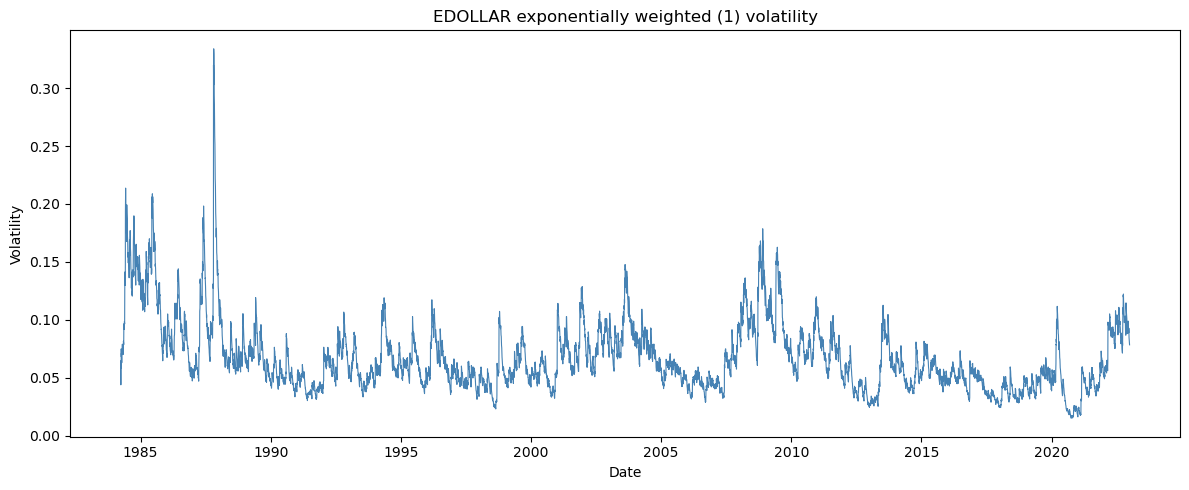

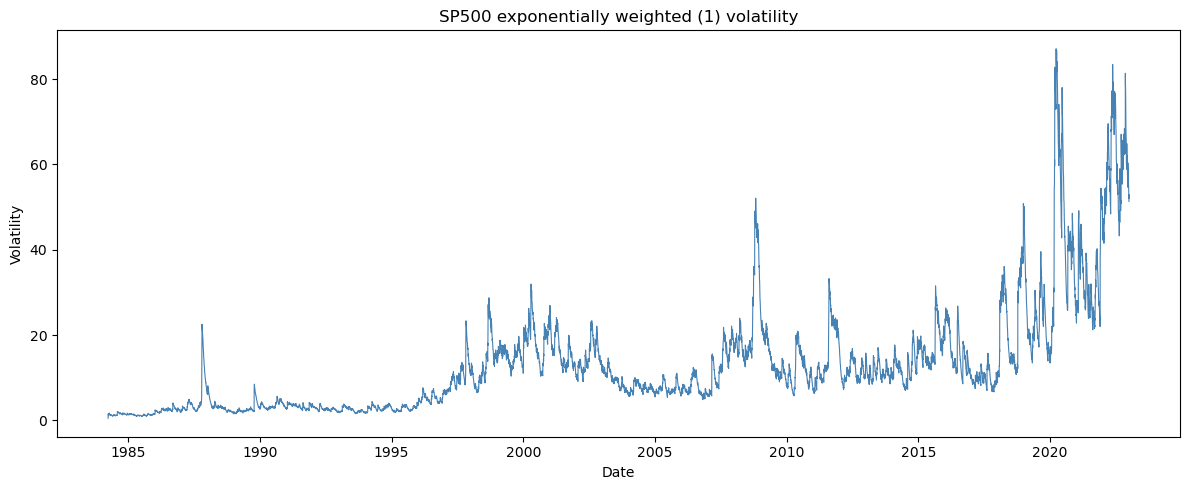

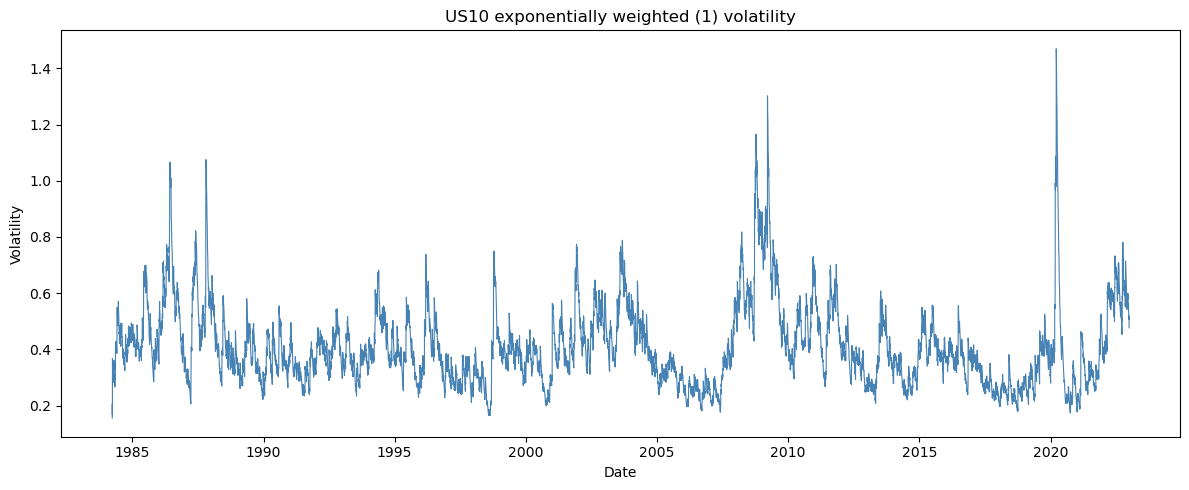

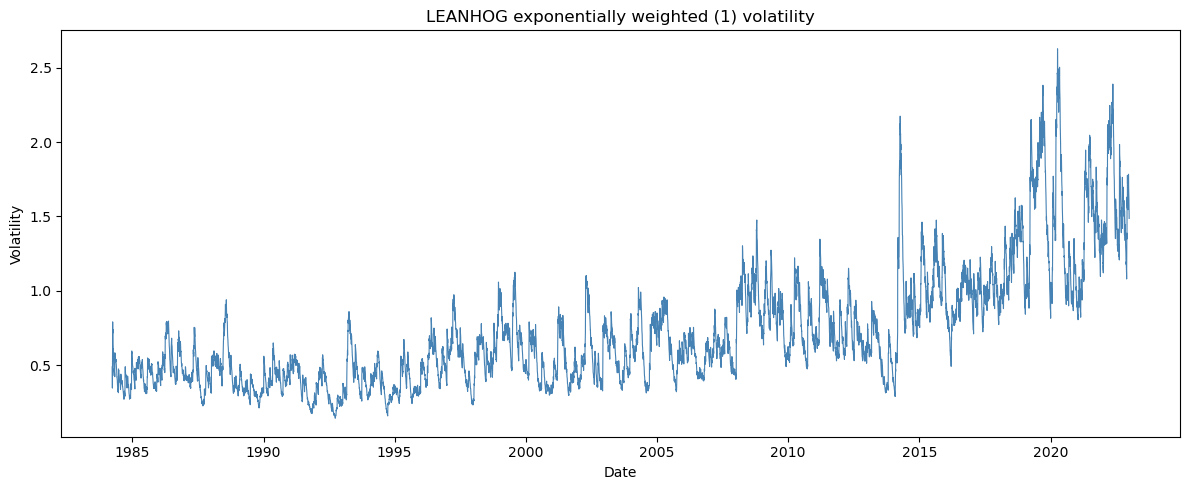

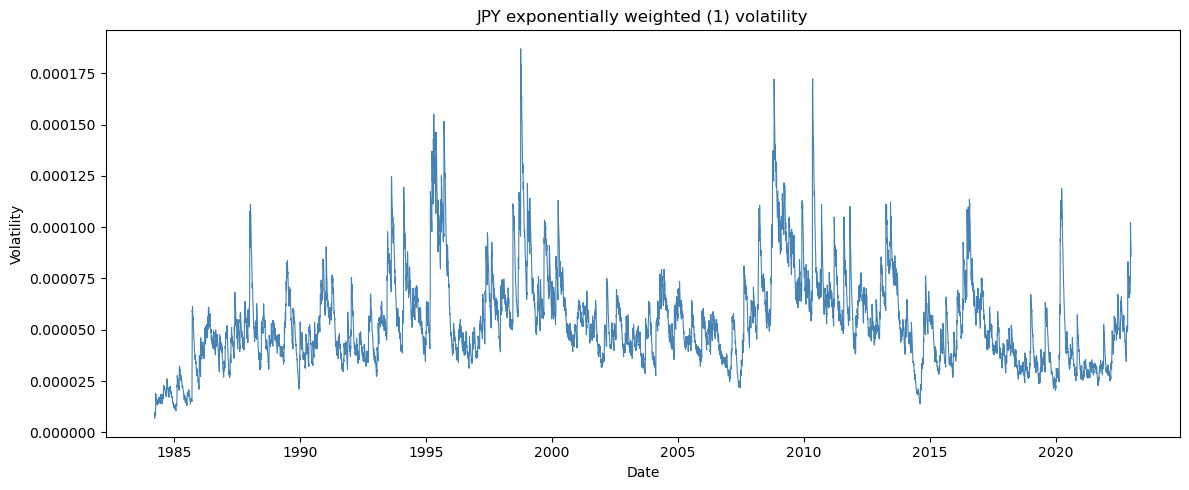

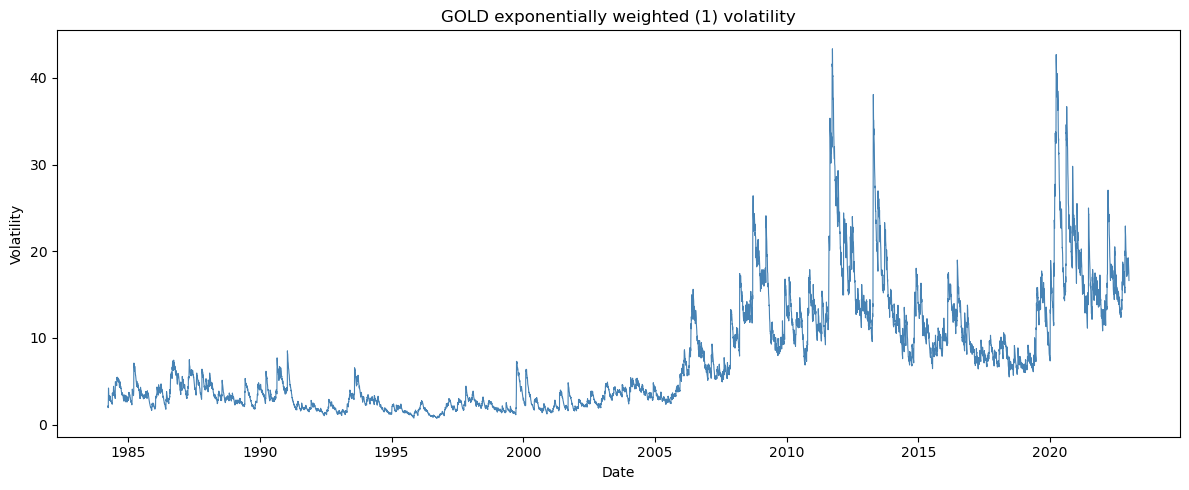

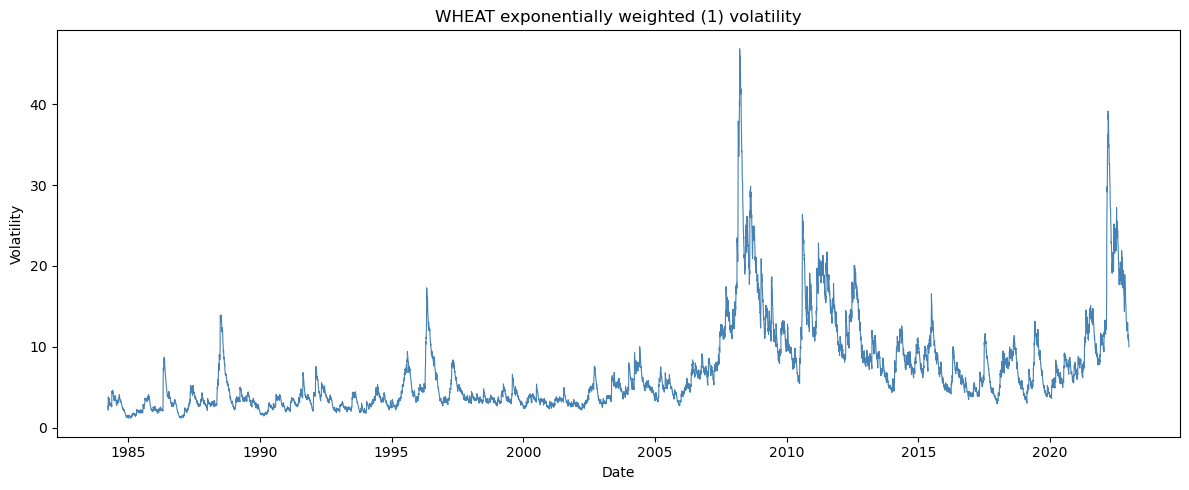

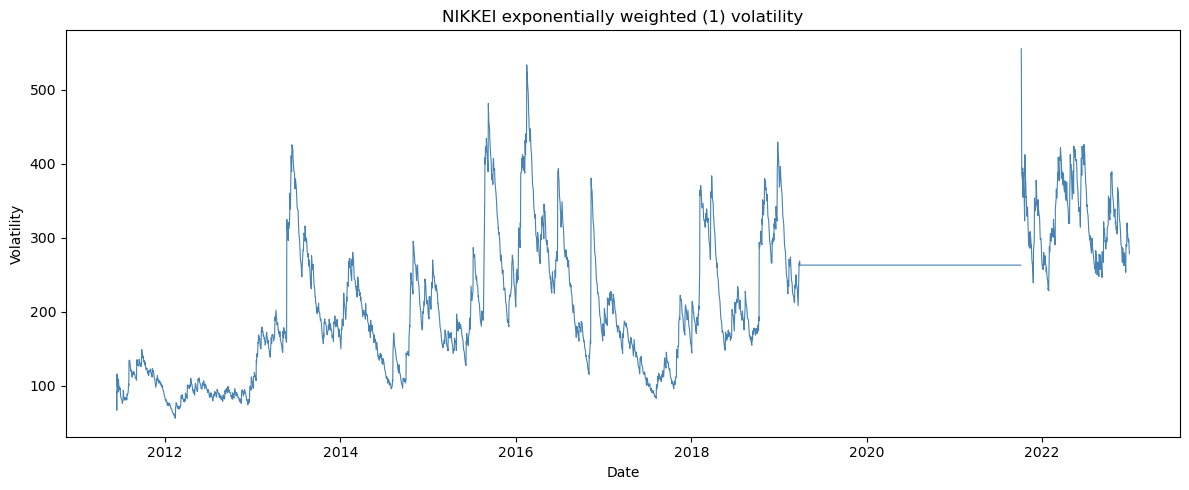

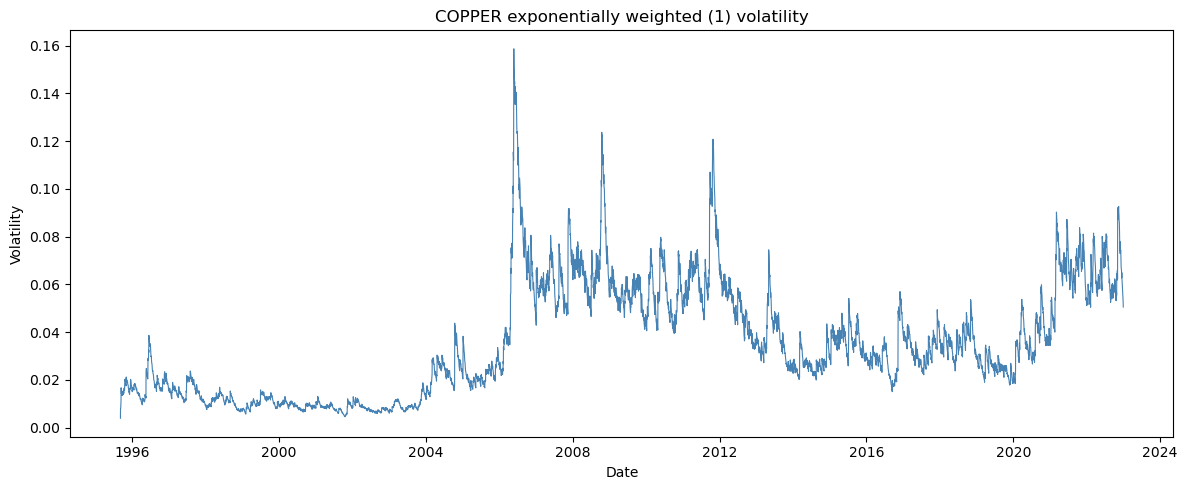

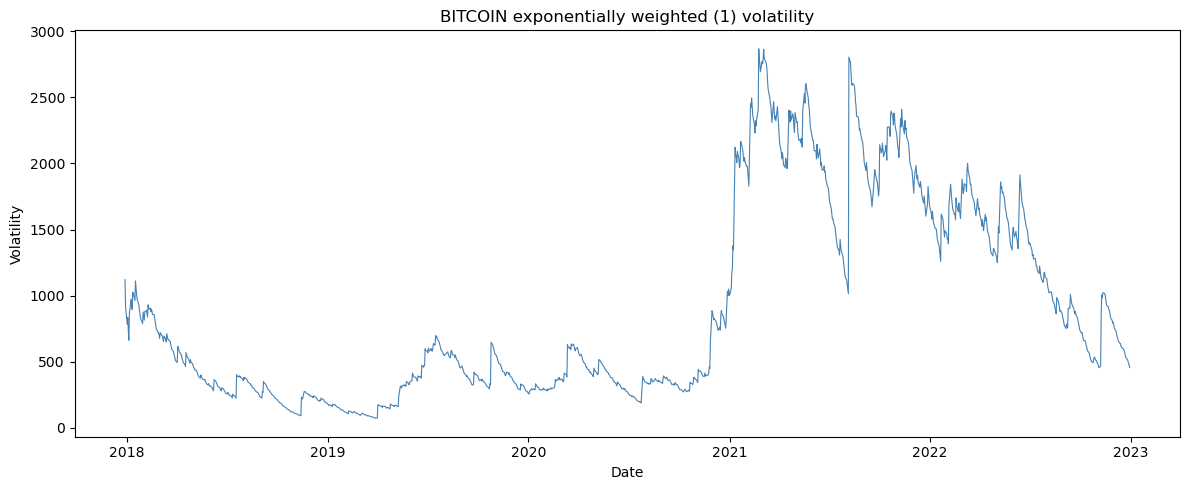

In [6]:
import matplotlib.pyplot as plt
import numpy as np

for col in exp_results:
    plt.figure(figsize=(12,5))
    plt.plot(df["Date"],exp_results[col], linewidth = 0.8, color = "steelblue", label = f"{col}")
    plt.title(f"{col} exponentially weighted (1) volatility")
    plt.ylabel("Volatility")
    plt.xlabel("Date")
    plt.tight_layout()
    plt.show()

## Estimate 2 - Exponential Weighting with Fast/Slow Averages

**The estimate that I will be using - forms a blended version of the 
volatility to consider volatility clustering without neglecting long 
term volatility results**

In [7]:
def compute_ewma_vol(price_series, fast_span=32, slow_window=2560, blend_fast=0.7, blend_slow=0.3, min_obs=60):
    diffs = price_series.diff()

    # Fast Component
    fast_vol = diffs.ewm(span=fast_span, min_periods=min_obs).std()
    
    # Slow component
    slow_vol = diffs.ewm(span=slow_window, min_periods=min_obs).std()
    
    blended_vol = blend_fast * fast_vol + blend_slow * slow_vol

    return blended_vol

vol_dict2 = {}
for col in df.columns[1:]:
    s = df[col].diff()
    vol_dict2[col] = compute_ewma_vol(s)

exp_results2 = pd.DataFrame(vol_dict2)
exp_results2 = exp_results.set_index(df["Date"])
print(exp_results2)

             EDOLLAR      SP500      US10   LEANHOG       JPY       GOLD  \
Date                                                                       
1984-03-23       NaN        NaN       NaN       NaN       NaN        NaN   
1984-03-26       NaN        NaN       NaN       NaN       NaN        NaN   
1984-03-27  0.063640   0.494975  0.154680  0.487904  0.000008   2.050610   
1984-03-28  0.046401   1.103888  0.206342  0.346105  0.000007   2.172995   
1984-03-29  0.043971   1.519936  0.166927  0.345028  0.000010   1.952416   
...              ...        ...       ...       ...       ...        ...   
2022-12-26  0.082090  54.345756  0.506819  1.642389  0.000092  18.078640   
2022-12-27  0.081950  52.704857  0.519286  1.608411  0.000090  17.866585   
2022-12-28  0.081027  52.021429  0.506402  1.558973  0.000089  17.562306   
2022-12-29  0.079779  52.944497  0.491201  1.532452  0.000088  17.141986   
2022-12-30  0.078489  51.322428  0.476433  1.486955  0.000086  16.619215   

           

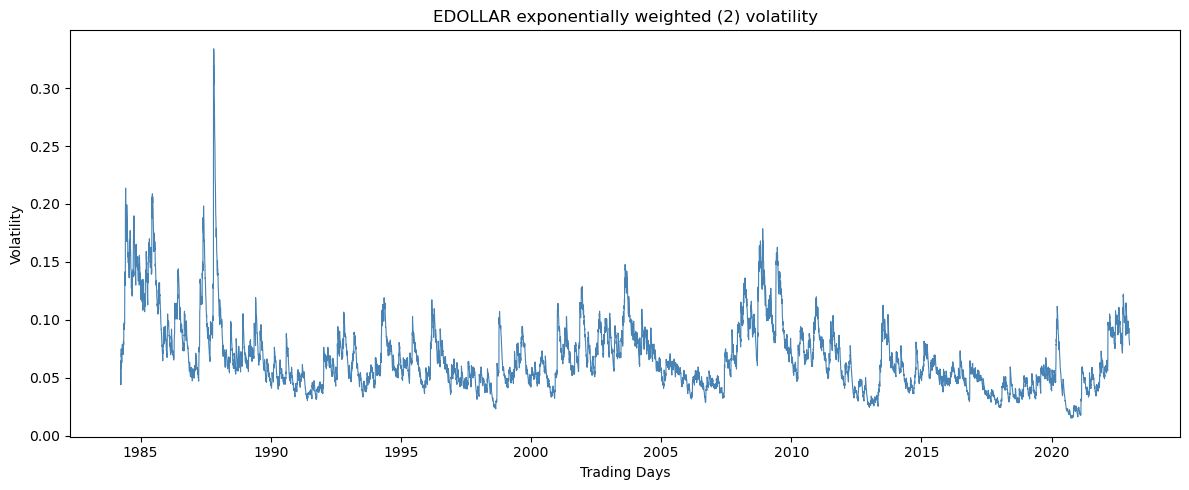

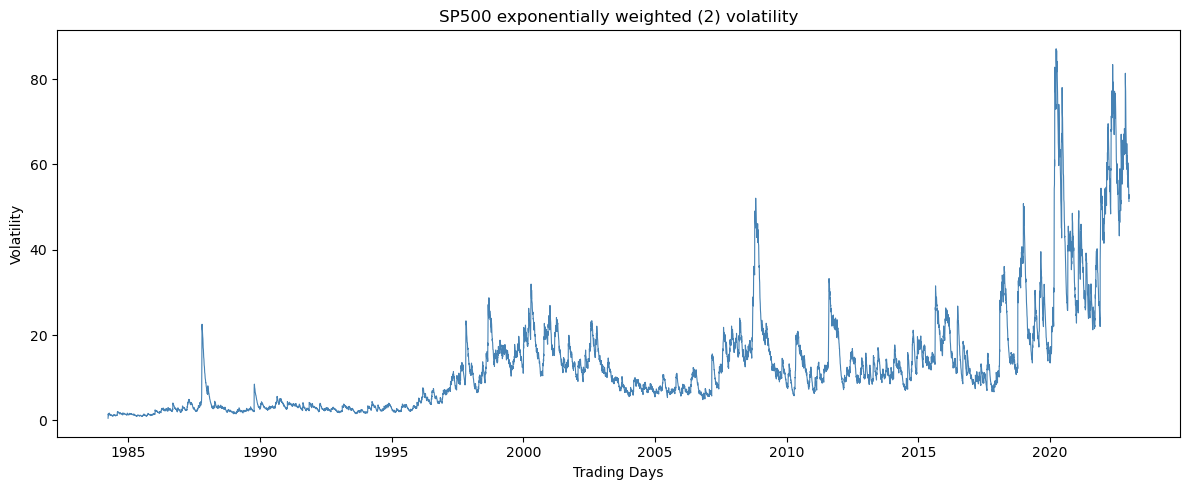

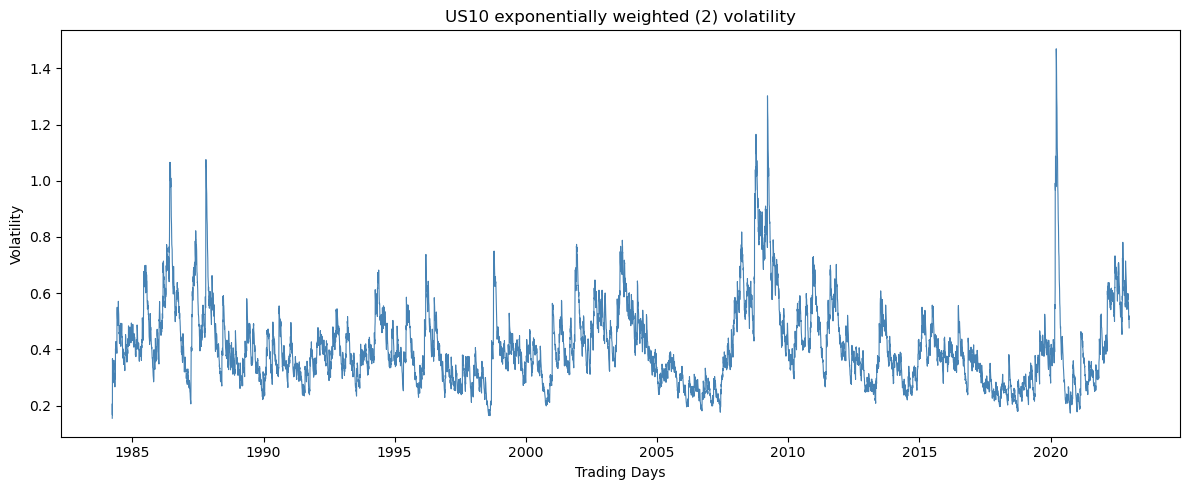

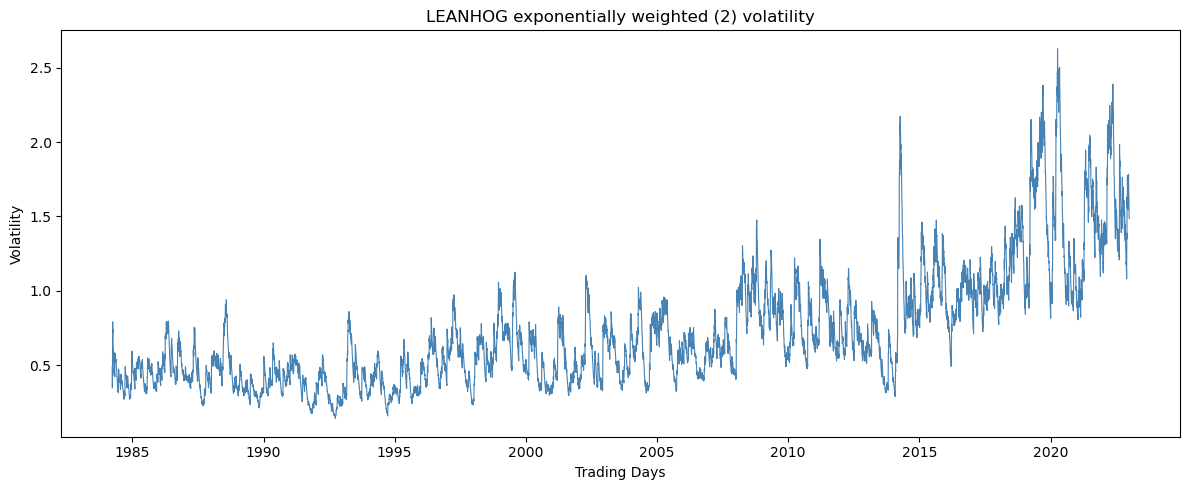

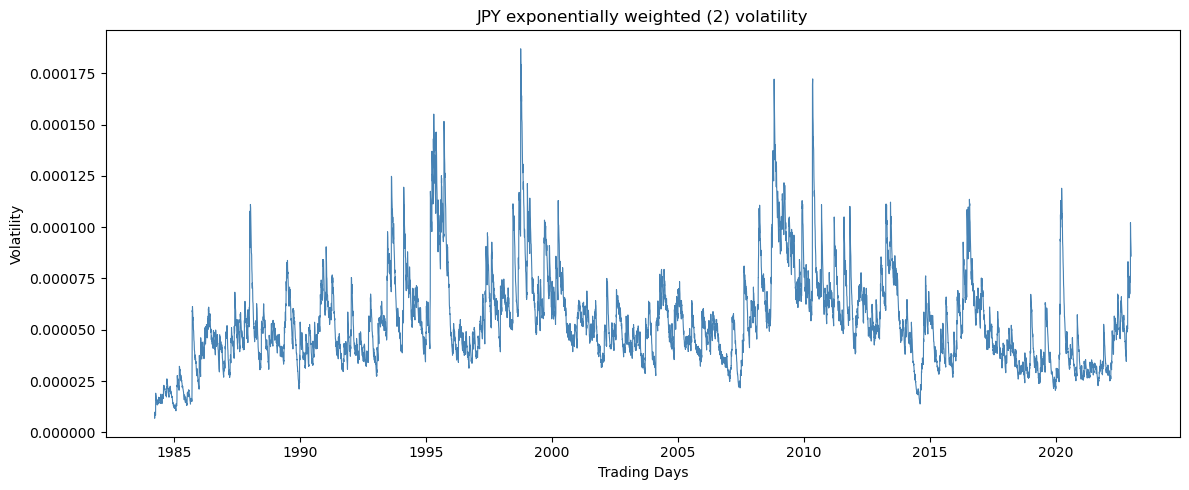

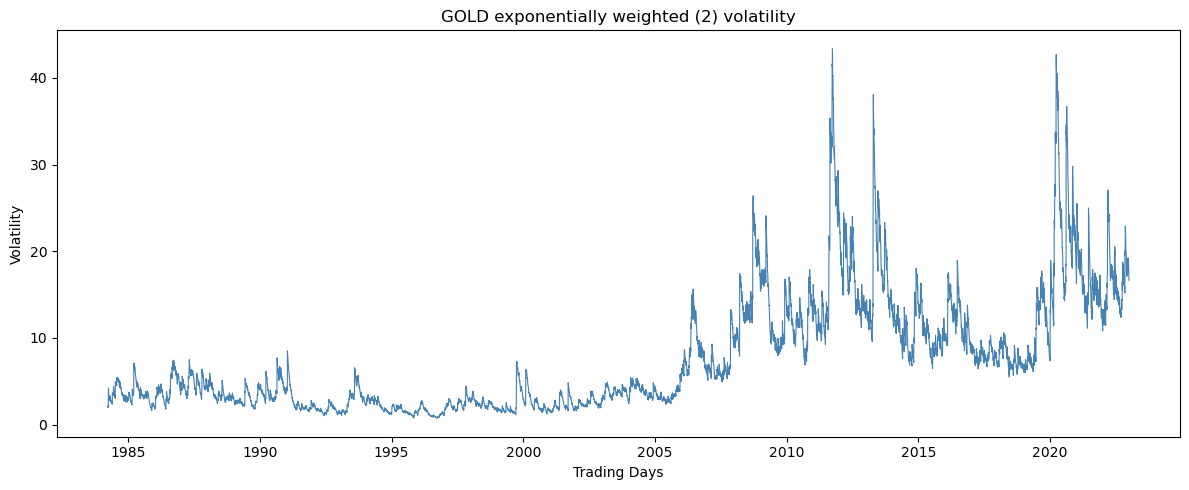

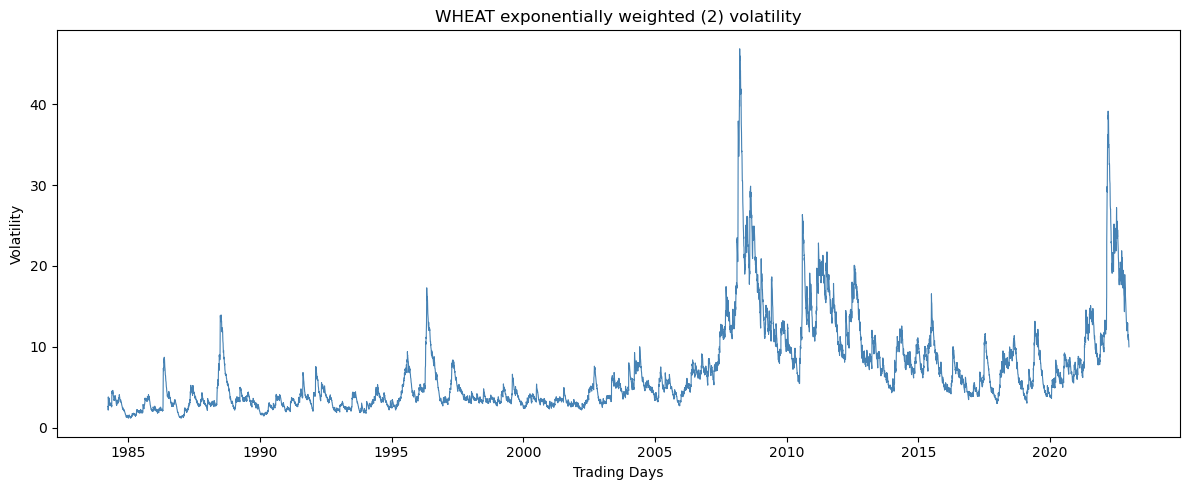

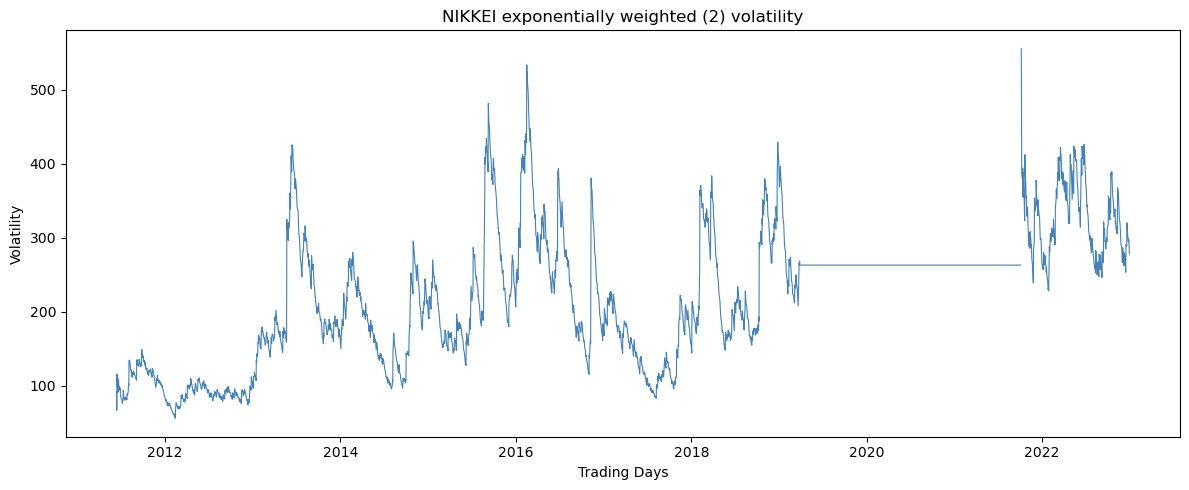

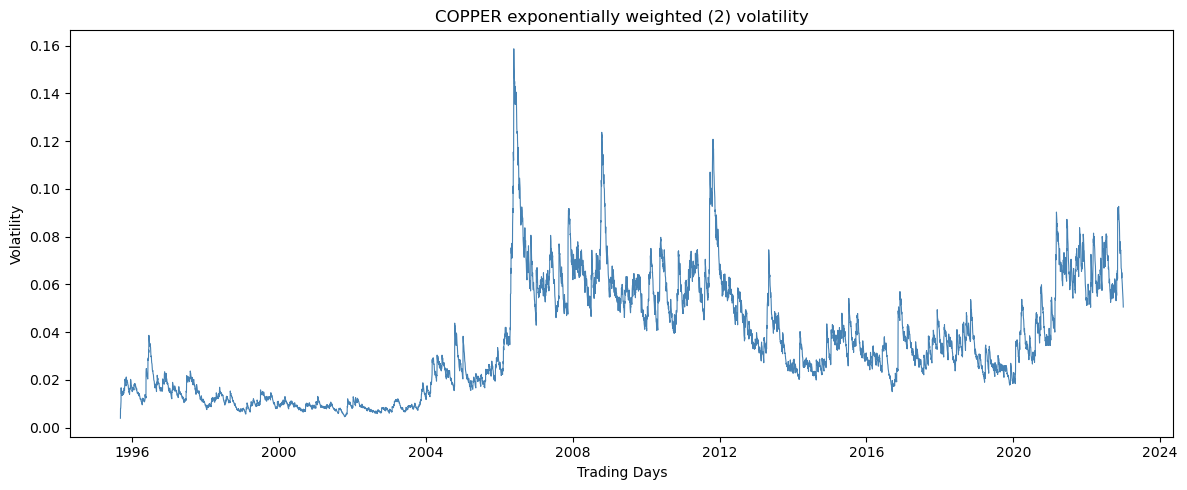

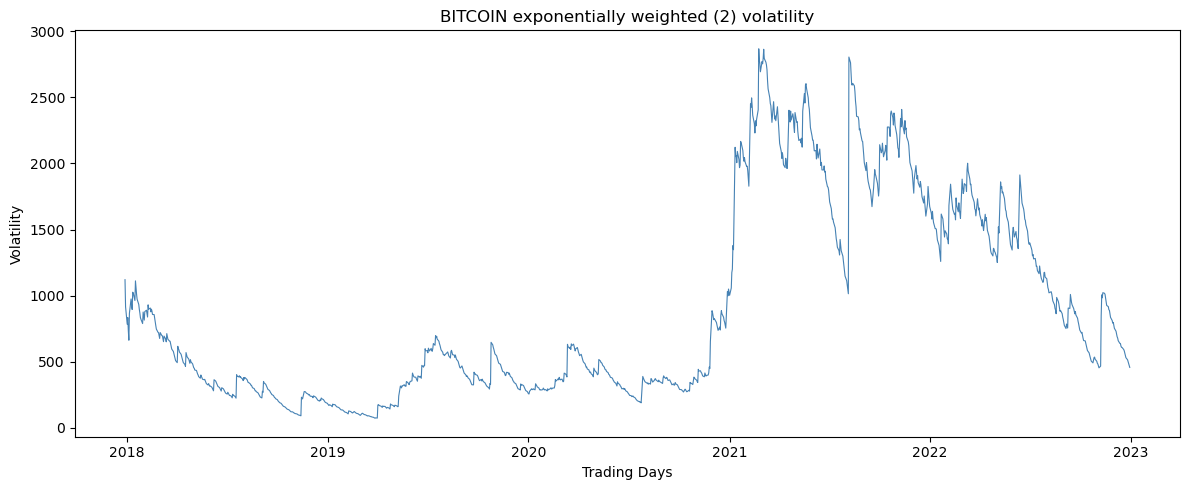

In [8]:
for col in exp_results2:
    plt.figure(figsize=(12,5))
    plt.plot(df["Date"], exp_results2[col], linewidth = 0.8, color = "steelblue", label = f"{col}")
    plt.title(f"{col} exponentially weighted (2) volatility")
    plt.ylabel("Volatility")
    plt.xlabel("Trading Days")
    plt.tight_layout()
    plt.show()

## Troubleshooting:

**NIKKEI Data** has a straight line bridging the gap in the exclusion period which is not true as we are not using this data; to follow is some code which tries to understand why this is happening.

In [9]:
gap_check = exp_results.loc["2019-04-01":"2021-10-01", "NIKKEI"]
print(gap_check.isna().all())   # should print True

gap_check = exp_results.loc["2019-04-01":"2021-10-01", "NIKKEI"]
print("Total rows in window:", len(gap_check))
print("Non-NaN rows in window:", gap_check.notna().sum())

# show exactly which dates have real values
bad_rows = df.loc[df["Date"].between("2019-04-01","2021-10-01") & exp_results["NIKKEI"].notna(), "Date"]
print(bad_rows)

print(df.loc[df["Date"].between("2019-04-01","2021-10-01"), "NIKKEI"].notna().sum())

diffs2 = df["NIKKEI"].diff()
print(diffs2.loc[df["Date"].between("2019-04-01","2021-10-01")].describe())

False
Total rows in window: 655
Non-NaN rows in window: 655
Series([], Name: Date, dtype: datetime64[ns])
0
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: NIKKEI, dtype: float64


This shows the calculation for volatility inputs data unexpectedly in the NaN region, so I will exclude this data for NIKKEI.

Non-NaN values remaining in excluded window: 0


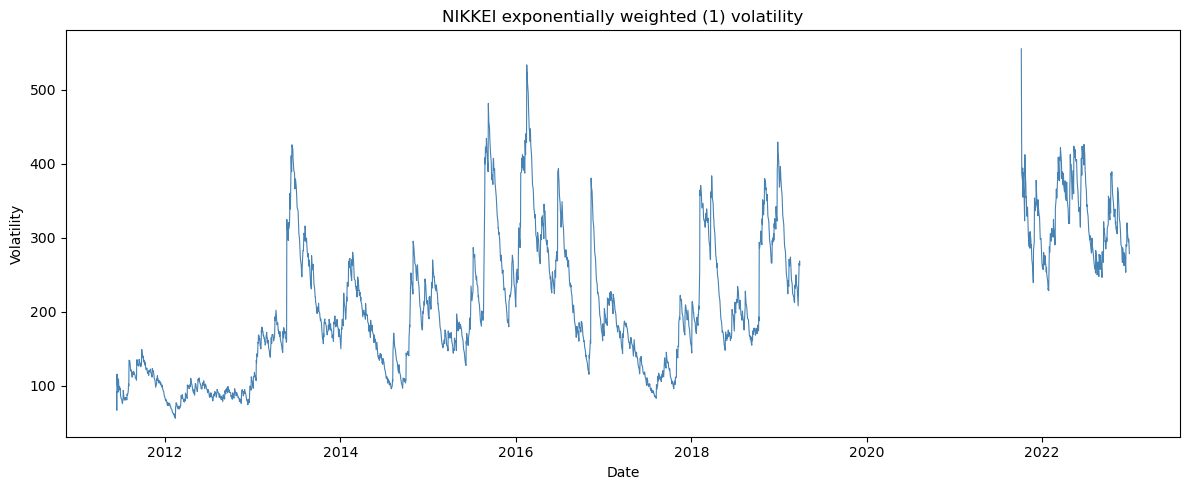

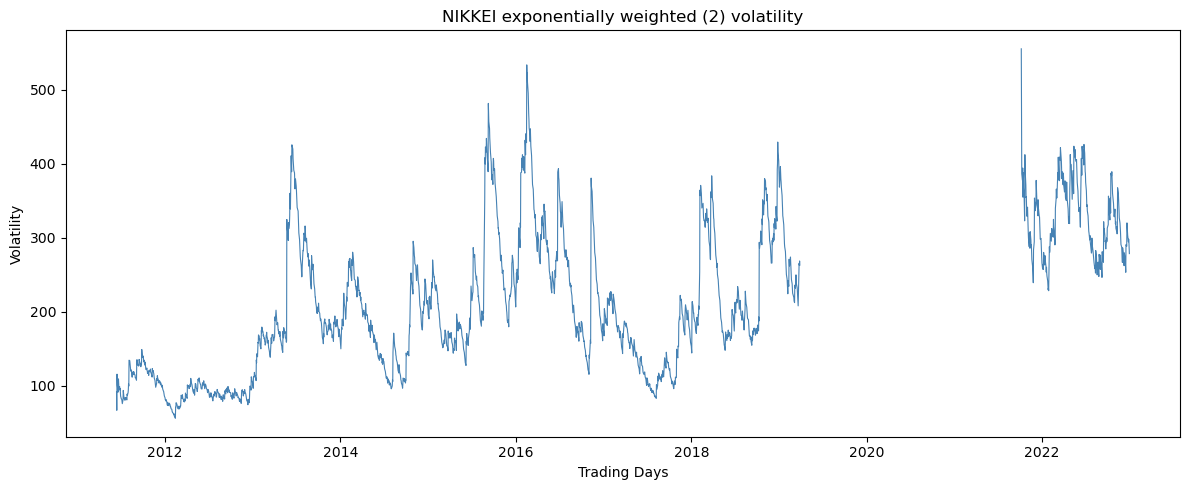

In [10]:
exp_results.loc["2019-04-01":"2021-10-01", "NIKKEI"] = pd.NA
exp_results2.loc["2019-04-01":"2021-10-01", "NIKKEI"] = pd.NA

check = exp_results.loc["2019-04-01":"2021-10-01", "NIKKEI"]
print("Non-NaN values remaining in excluded window:", check.notna().sum())

plt.figure(figsize=(12,5))
plt.plot(df["Date"],exp_results["NIKKEI"], linewidth = 0.8, color = "steelblue", label = f"{col}")
plt.title("NIKKEI exponentially weighted (1) volatility")
plt.ylabel("Volatility")
plt.xlabel("Date")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))
plt.plot(df["Date"], exp_results2["NIKKEI"], linewidth = 0.8, color = "steelblue", label = f"{col}")
plt.title("NIKKEI exponentially weighted (2) volatility")
plt.ylabel("Volatility")
plt.xlabel("Trading Days")
plt.tight_layout()
plt.show()

## 2. Signal Design

**Designing momentum, mean reversion and breakout signals**

## 2.1. Momentum Signal

**Experimenting with lookback windows:** For simplicity, my momentum signal will run based on the idea of a
lookback window, where the price difference to be used will be today's
price minus the price from X days ago. This will then be normalised
and used to generate a signal for each asset.